# Crelan Application Scoring Model
## 1. Setup and Imports
We import all the necessary Python libraries for data manipulation, visualization, machine learning pipelines, and model evaluation.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from category_encoders import TargetEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, recall_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

## 2. Data Understanding
We load the training dataset into a Pandas DataFrame and define our target feature `IN_DEFAULT_FLG`. We then generate a general statistical description of the dataset to get a first impression of the numerical distributions.

In [2]:
# Target feature: IN_DEFAULT_FLG (1 = default, 0 = no default)
target_feature = "IN_DEFAULT_FLG"

# Loading the dataset in a pandas DataFrame
try:
    base_path = Path(__file__).resolve().parent
except NameError:
    base_path = Path.cwd()

training_dataset = pd.read_excel(base_path / "DSC_training.xlsx", na_values=np.nan)

# describing the dataset 
print(training_dataset.describe())
print("")

       ACTIVE_CREDITS_FLG  APPLICANTS_CNT                 APPLICATION_DT  \
count         7579.000000     7638.000000                           7638   
mean             0.684787        1.443572  2018-06-26 17:25:46.897093632   
min              0.000000        1.000000            2014-07-30 00:00:00   
25%              0.000000        1.000000            2016-12-06 06:00:00   
50%              1.000000        1.000000            2018-07-03 00:00:00   
75%              1.000000        2.000000            2020-01-08 00:00:00   
max              1.000000        5.000000            2022-01-26 00:00:00   
std              0.464631        0.506237                            NaN   

        APPLIED_AMT  COLLATERAL_AMT  CREDIT_INTER_PRIV_PERIODIC_MTHS  \
count  7.638000e+03    7.638000e+03                      5865.000000   
mean   3.388614e+04    6.102100e+04                         9.468883   
min    1.500000e+03    0.000000e+00                         1.000000   
25%    1.000000e+04    0.00

## 3. Data Exploration and Quality Examination (EDA)
We analyse the structure of the data and the class distribution of our target variable. 
Next, we check for multicollinearity using a correlation matrix, analyse categorical risk drivers with a contingency table, and visualize outliers using bivariate boxplots.
! CODE ADDED 2ND TERM !

First 10 rows of the dataset:
   ACTIVE_CREDITS_FLG  APPLICANTS_CNT APPLICATION_BY_EMPLOYEE_FLG  \
0                 1.0               1                           N   
1                 NaN               2                           N   
2                 0.0               1                           N   
3                 1.0               1                           N   
4                 1.0               1                           N   
5                 0.0               1                           N   
6                 0.0               1                           N   
7                 0.0               1                           N   
8                 0.0               1                           N   
9                 1.0               1                           N   

  APPLICATION_DT  APPLIED_AMT  COLLATERAL_AMT  \
0     2018-03-02       4777.8             0.0   
1     2019-12-13      25000.0             0.0   
2     2017-07-18      15000.0             0.0   
3     2016-08-

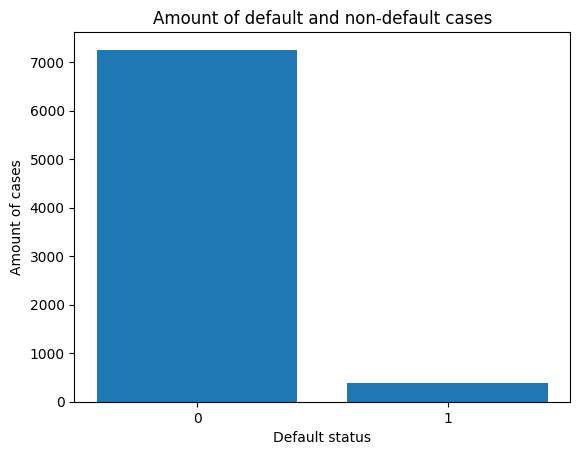

Correlation matrix:


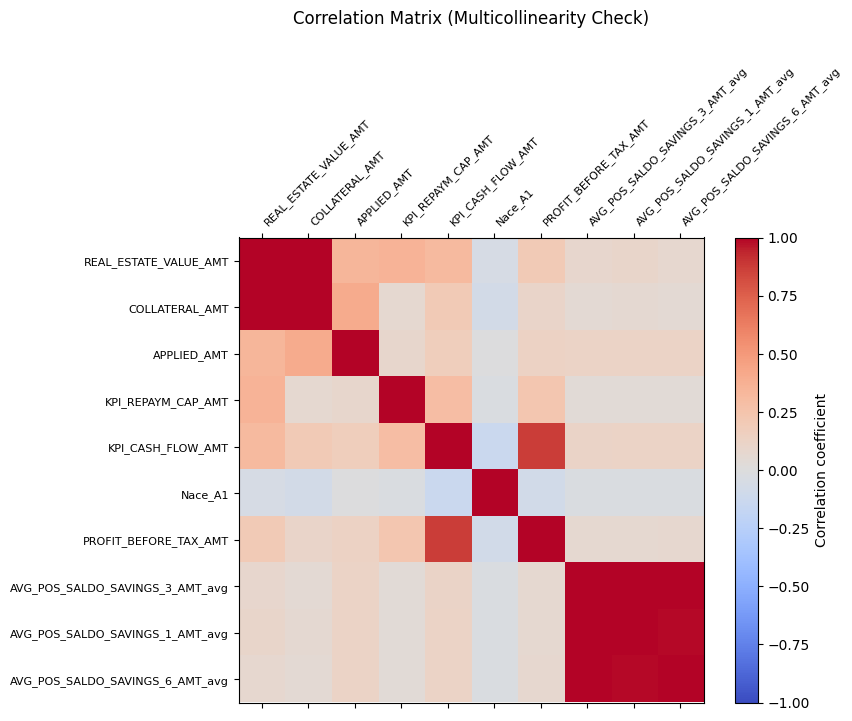

Contingency table for categorical variables:
--- Contingency Table: FINANCIAL_PRODUCT_TYPE_CD vs IN_DEFAULT_FLG ---
Raw Counts:
IN_DEFAULT_FLG                0    1   All
FINANCIAL_PRODUCT_TYPE_CD                 
LON                         855  122   977
MTG                        6398  263  6661
All                        7253  385  7638



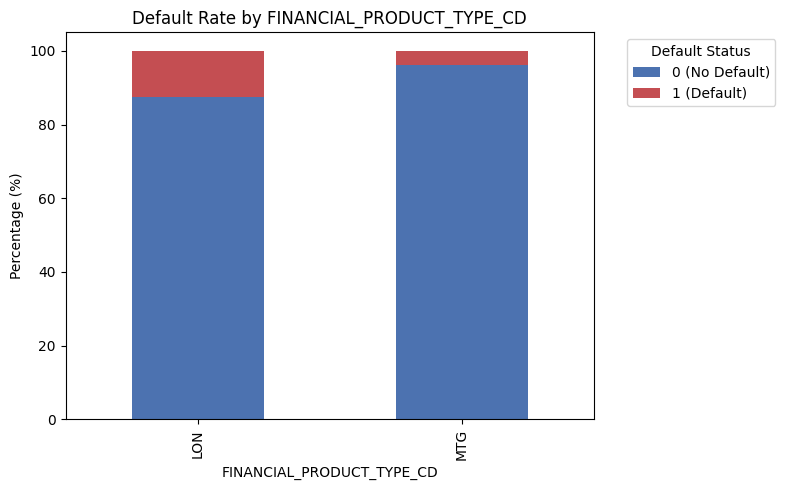

Bivariate analysis: Boxplot of the numerical variable with the strongest correlation to the target variable
--- Bivariate Analysis: Gender_A3 vs IN_DEFAULT_FLG ---
Correlation coefficient: 0.2303


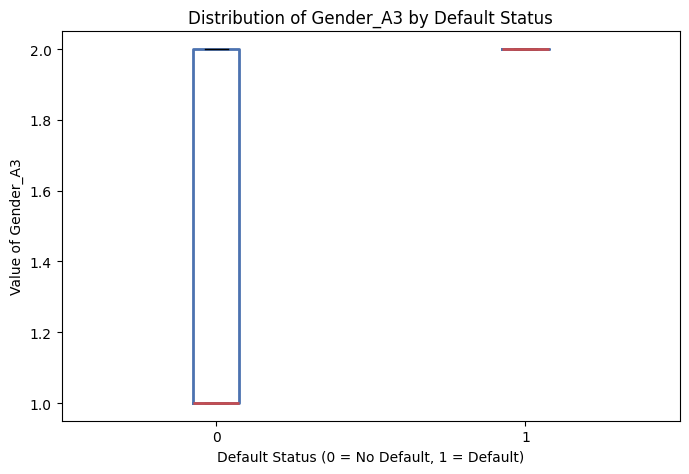

In [3]:
# printing the 10 first rows of the dataset to get a first impression
print("First 10 rows of the dataset:")
print(training_dataset.head(10))
print("")

# looking at the structure of the dataset
print("Information about the dataset:")
print(training_dataset.info())
print("")

# looking at the rows and columns of the dataset in terms of shape (#rows, #columns)
print("Shape of the dataset (#rows, #columns):")
print(training_dataset.shape)
print("")

# Percentage of default cases for the target variable "IN_DEFAULT_FLG"
default_percentage = training_dataset['IN_DEFAULT_FLG'].mean() * 100
print("Amount of default cases:", default_percentage, "%")
print("")

# Visualizing the distribution of default cases
counts = training_dataset['IN_DEFAULT_FLG'].value_counts()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Default status")
plt.ylabel("Amount of cases")
plt.title("Amount of default and non-default cases")
plt.show()

######### ADDED 2ND TERM ########
# printing a correlation matrix to check for multicollinearity 
print("Correlation matrix:")

# select only numerical columns (excluding the target feature)
num_cols_eda = training_dataset.select_dtypes(include=[np.number]).columns.tolist()
if target_feature in num_cols_eda:
    num_cols_eda.remove(target_feature)

if len(num_cols_eda) > 0:
    # select top 10 numerical features with the highest variance
    top_num_cols = training_dataset[num_cols_eda].var().nlargest(10).index.tolist()
    
    # compute the correlation matrix
    corr_matrix = training_dataset[top_num_cols].corr()
    
    # plot the matrix as a heatmap
    plt.figure(figsize=(8, 6))
    plt.matshow(corr_matrix, fignum=1, cmap='coolwarm', vmin=-1, vmax=1)
    plt.xticks(range(len(top_num_cols)), top_num_cols, rotation=45, ha='left', fontsize=8)
    plt.yticks(range(len(top_num_cols)), top_num_cols, fontsize=8)
    plt.colorbar(label="Correlation coefficient")
    plt.title("Correlation Matrix (Multicollinearity Check)", pad=30)
    plt.tight_layout()
    plt.show()

# printing a contingency table to check for relationships between categorical variables and the target variable
print("Contingency table for categorical variables:")
cat_cols_eda = training_dataset.select_dtypes(include=['object', 'category']).columns.tolist()

if cat_cols_eda:
    selected_cat_col = None
    for col in cat_cols_eda:
        if training_dataset[col].nunique() < 10 and training_dataset[col].nunique() > 1:
            selected_cat_col = col
            break
    
    if selected_cat_col:
        print(f"--- Contingency Table: {selected_cat_col} vs {target_feature} ---")
        crosstab_counts = pd.crosstab(training_dataset[selected_cat_col], training_dataset[target_feature], margins=True)
        print("Raw Counts:")
        print(crosstab_counts)
        print("")
        
        crosstab_pct = pd.crosstab(training_dataset[selected_cat_col], training_dataset[target_feature], normalize='index') * 100
        
        crosstab_pct.plot(kind='bar', stacked=True, color=['#4C72B0', '#C44E52'], figsize=(8, 5))
        plt.title(f"Default Rate by {selected_cat_col}")
        plt.xlabel(selected_cat_col)
        plt.ylabel("Percentage (%)")
        plt.legend(title="Default Status", labels=["0 (No Default)", "1 (Default)"], bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("No low-cardinality categorical variables found for a clear contingency table.")
else:
    print("No categorical columns found.")

# printing boxplot 
print("Bivariate analysis: Boxplot of the numerical variable with the strongest correlation to the target variable")
if len(num_cols_eda) > 0:
    corrs_with_target = training_dataset[num_cols_eda].corrwith(training_dataset[target_feature])
    top_feature = corrs_with_target.abs().idxmax()
    
    print(f"--- Bivariate Analysis: {top_feature} vs {target_feature} ---")
    print(f"Correlation coefficient: {corrs_with_target[top_feature]:.4f}")
    
    training_dataset.boxplot(column=top_feature, by=target_feature, figsize=(7, 5), grid=False, 
                             boxprops=dict(color='#4C72B0', linewidth=2),
                             medianprops=dict(color='#C44E52', linewidth=2),
                             flierprops=dict(marker='o', color='black', alpha=0.3))
    
    plt.title(f"Distribution of {top_feature} by Default Status")
    plt.suptitle("")
    plt.xlabel("Default Status (0 = No Default, 1 = Default)")
    plt.ylabel(f"Value of {top_feature}")
    plt.tight_layout()
    plt.show()
    print("")
else:
    print("No numerical columns available for bivariate analysis.")

## 4. Data Preparation (Formatting & Datetimes)
Financial data often contains formatting issues (e.g., commas instead of decimal points). We coerce these key financial columns into workable floats. 
Next, we extract useful features from datetime columns (Year, Month, Day) and drop the original datetime strings.

In [4]:
# Unified helper to coerce strings with comma decimals and whitespace into floats
def coerce_decimal_comma_to_series(series, default=np.nan):
    if series is None:
        return pd.Series([], dtype=float)
    try:
        idx = series.index
    except Exception:
        idx = None
    s = pd.Series(series).astype(str).str.strip().replace(r'\s+', '', regex=True)
    s = s.str.replace(",", ".", regex=False)
    out = pd.to_numeric(s, errors='coerce').fillna(float(default)).astype(float)
    if idx is not None and len(out) == len(idx):
        out.index = idx
    return out

# Financial column names
_ead_col = "APPLIED_AMT"
_lgd_col = "LOSS_GIVEN_DEFAULT_PCT"

# Coerce financial columns in the training dataset 
if _ead_col in training_dataset.columns:
    training_dataset[_ead_col] = coerce_decimal_comma_to_series(training_dataset[_ead_col], default=np.nan)

if _lgd_col in training_dataset.columns:
    training_dataset[_lgd_col] = coerce_decimal_comma_to_series(training_dataset[_lgd_col], default=np.nan)

selected_columns = training_dataset.copy()

# Safer datetime detection
def likely_datetime_column(name: str) -> bool:
    if not isinstance(name, str):
        return False
    n = name.lower()
    return ('date' in n) or ('timestamp' in n) or n.endswith('_dt') or n.endswith('_date') or n.endswith('_timestamp')

# Try to convert possible datetime columns
for col in selected_columns.columns:
    if col == target_feature:
        continue
    if likely_datetime_column(col):
        try:
            selected_columns[col] = pd.to_datetime(
                selected_columns[col], errors='raise', format='%Y-%m-%d %H:%M:%S'
            )
        except (ValueError, TypeError):
            try:
                selected_columns[col] = pd.to_datetime(selected_columns[col], errors='coerce')
            except Exception:
                pass

datetime_cols = selected_columns.select_dtypes(include=['datetime', 'datetime64', 'datetimetz']).columns.tolist()

# Datetime feature expansion
new_cols = {}
for col in datetime_cols:
    new_cols[col + '_year'] = selected_columns[col].dt.year
    new_cols[col + '_month'] = selected_columns[col].dt.month
    new_cols[col + '_day'] = selected_columns[col].dt.day

if new_cols:
    datetime_features_df = pd.DataFrame(new_cols, index=selected_columns.index)
    selected_columns = pd.concat([selected_columns.drop(columns=datetime_cols), datetime_features_df], axis=1)

## 5. Data Splitting and Feature Filtering
To prevent data leakage, we perform a stratified split to ensure the class distribution is maintained. We create a 64% Training, 16% Validation, and 20% Test set. 
Features consisting almost entirely of missing values or zeroes are identified only on the training fold, and then dropped globally.

In [5]:
n = len(selected_columns)
indices_all = np.arange(n)

# stratified split: 80% train + val, 20% test
indices_train, indices_test = train_test_split(
    indices_all, test_size=0.2, random_state=0, stratify=selected_columns[target_feature].iloc[indices_all]
)

# stratified split of train -> train (80% of train + val) and val (20% of train+val)
indices_train, indices_val = train_test_split(
    indices_train, test_size=0.2, random_state=0, stratify=selected_columns[target_feature].iloc[indices_train]
)

# LGD normalization based on training fold only 
if _lgd_col in selected_columns.columns:
    try:
        if np.nanmedian(selected_columns.loc[indices_train, _lgd_col]) > 1.0:
            selected_columns[_lgd_col] = selected_columns[_lgd_col] / 100.0
    except Exception:
        pass

# determine columns to drop based on training fold only
def determine_columns_to_drop(df, target_feature, missing_thresh=90.0, zero_thresh=95.0):
    missing_percentage = df.isna().mean() * 100
    zero_percentage = pd.Series(0.0, index=df.columns)
    num_cols_local = df.select_dtypes(include=[np.number]).columns
    if len(num_cols_local) > 0:
        zero_percentage[num_cols_local] = (df[num_cols_local] == 0).mean() * 100

    missing_cols = [c for c in df.columns if missing_percentage[c] > missing_thresh and c != target_feature]
    zero_cols = [c for c in df.columns if zero_percentage[c] > zero_thresh and c != target_feature]
    cols_to_drop = list(set(missing_cols + zero_cols))
    return cols_to_drop

cols_to_drop = determine_columns_to_drop(selected_columns.iloc[indices_train], target_feature)
print("Columns to drop (determined on training set):", cols_to_drop)
print("")

if cols_to_drop:
    selected_columns = selected_columns.drop(columns=cols_to_drop)

X = selected_columns.drop(target_feature, axis=1)
y = selected_columns[target_feature]

# Raw splits 
X_train = X.iloc[indices_train].copy()
X_val   = X.iloc[indices_val].copy()
X_test  = X.iloc[indices_test].copy()
y_train = y.iloc[indices_train].copy()
y_val   = y.iloc[indices_val].copy()
y_test  = y.iloc[indices_test].copy()

print("Split sizes (train/val/test):", X_train.shape, X_val.shape, X_test.shape)
print("")

Columns to drop (determined on training set): ['TOT_DOMIC_CREDCD_COREPROF_AMT_MX', 'BEH_SCORE_AVG_A2', 'TOT_DOM_EXC_CRE_INT_PRIV_CNT_max', 'BEH_SCORE_MIN_A3', 'BEH_SCORE_AVG_A3', 'BEH_SCORE_MIN_A2', 'nationality_A3', 'birth_dt_A3', 'TOT_DOM_EXC_CRE_INT_PROF_CNT_max', 'LOSS_YEAR_AMT', 'MONTHS_IN_BELGIUM_CNT_min', 'Gender_A3', 'TOT_DOM_EXC_CRE_INT_PROF_AMT_max', 'TOT_DOM_EXC_CRE_INT_PRIV_AMT_max', 'MTHS_IN_BUSINESS_CNT']

Split sizes (train/val/test): (4888, 163) (1222, 163) (1528, 163)



## 6. Preprocessing Pipelines
We construct pipelines to handle missing values, scaling, and categorical encoding.
We built a custom clipper to cap extreme numerical outliers at 3 standard deviations without deleting the underlying records. 
High-cardinality categorical variables are processed using Target Encoding.

In [6]:
# Helper: choose a OneHotEncoder that works across scikit-learn versions
def make_onehot_encoder(drop='first', handle_unknown='ignore'):
    try:
        return OneHotEncoder(handle_unknown=handle_unknown, drop=drop, sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown=handle_unknown, drop=drop, sparse=False)

# Wrapper so TargetEncoder works inside ColumnTransformer 
class TargetEncoderWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None, min_samples_leaf=5, smoothing=2.0):
        self.min_samples_leaf = min_samples_leaf
        self.smoothing = smoothing
        self.cols = cols
        self.encoder_ = None
        self.fitted_cols_ = None

    def fit(self, X, y=None):
        if y is None: raise ValueError("TargetEncoderWrapper requires y for fit.")
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.cols or [f"col_{i}" for i in range(X.shape[1])], index=y.index if isinstance(y, pd.Series) else None)
        cols_for_encoder = list(X_df.columns)
        self.encoder_ = TargetEncoder(cols=cols_for_encoder, min_samples_leaf=self.min_samples_leaf, smoothing=self.smoothing)
        self.encoder_.fit(X_df, y)
        self.fitted_cols_ = cols_for_encoder
        return self

    def transform(self, X):
        if self.encoder_ is None: raise RuntimeError("TargetEncoderWrapper not fitted")
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.cols or [f"col_{i}" for i in range(X.shape[1])])
        if self.fitted_cols_ is not None:
            X_df = X_df.reindex(columns=self.fitted_cols_)
        transformed = self.encoder_.transform(X_df)
        return transformed.values if isinstance(transformed, pd.DataFrame) else np.asarray(transformed)

# Custom transformer to clip values
class Clipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=-3.0, upper=3.0):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_arr = np.array(X, copy=True)
        np.clip(X_arr, self.lower, self.upper, out=X_arr)
        return X_arr

# Feature Engineering Lists
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

if cat_cols:
    nuniq = X_train[cat_cols].nunique(dropna=True)
    high_card_cols = nuniq[nuniq > 10].index.tolist()
    low_card_cols = nuniq[nuniq <= 10].index.tolist()
else:
    high_card_cols, low_card_cols = [], []

feature_names = list(X.columns)

# Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('clipper', Clipper(-3.0, 3.0))
])

low_card_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_onehot_encoder(drop='first', handle_unknown='ignore'))
])

high_card_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_enc', TargetEncoderWrapper(min_samples_leaf=5, smoothing=2.0))
])

transformers = []
if num_cols: transformers.append(('num', numeric_transformer, num_cols))
if low_card_cols: transformers.append(('low_cat', low_card_transformer, low_card_cols))
if high_card_cols: transformers.append(('high_cat', high_card_transformer, high_card_cols))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop', sparse_threshold=0)

## 7. Modeling Setup & Financial Metrics
We define our candidate models (Logistic Regression, Random Forest, XGBoost, etc.) alongside their hyperparameter grids. 
Next, we implement custom functions to calculate financial weights based on Exposure at Default (EAD) and Loss Given Default (LGD). This ensures our grid search optimizes for real business impact (Weighted ROC-AUC).

In [7]:
MODELS = {
    "logistic": LogisticRegression,
    "rf": RandomForestClassifier,
    "dt": DecisionTreeClassifier,
    "knn": KNeighborsClassifier,
    "svm": SVC,
    "xgb": XGBClassifier
}

HYPERPARAM = {
    "logistic": {"C": [0.001, 0.01, 0.1, 1.0]},
    "rf": {"n_estimators": [100, 200, 500], "min_samples_leaf": [1, 5], "max_depth": [None, 70], "random_state": [0]},
    "dt": {"criterion": ["gini", "entropy"], "max_depth": [None, 70], "min_samples_leaf": [2, 5, 10], "min_samples_split": [2], "random_state": [0]},
    "knn": {"n_neighbors": [5, 10, 20, 50]},
    "svm": {"C": [0.1, 1.0], "kernel": ["linear", "rbf"], "probability": [True]},
    "xgb": {"n_estimators": [100, 200], "max_depth": [3, 6, 10], "learning_rate": [0.01, 0.1],
            "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0], "reg_alpha": [0, 1], "reg_lambda": [1, 2], "random_state": [0]}
}

MODEL_DEFAULT_KWARGS = {
    "logistic": {"max_iter": 10000, "solver": "lbfgs"},
    "svm": {"probability": True},
    "rf": {"n_jobs": -1},
    "xgb": {"use_label_encoder": False, "verbosity": 0}
}

RANDOM_SEED = 0 
fitted_models = {}
model_results = {}

def _get_proba_or_scores(model, X_):
    try:
        proba = model.predict_proba(X_)
        if proba.ndim == 2 and proba.shape[1] >= 2: return np.asarray(proba[:, 1].astype(float))
        else: return np.asarray(proba.ravel().astype(float))
    except Exception: pass

    try: return np.asarray(model.decision_function(X_)).ravel().astype(float)
    except Exception: pass

    try:
        preds = model.predict(X_)
        warnings.warn(UserWarning)
        return np.asarray(preds).ravel().astype(float)
    except Exception as e:
        raise RuntimeError(f"couldn't get scores/proba/predict from model: {e}")

# Financial Weight Calculations
def coerce_scoring_df_for_financials(df, ead_col="APPLIED_AMT", lgd_col="LOSS_GIVEN_DEFAULT_PCT"):
    df2 = df.copy()
    if ead_col in df2.columns: df2[ead_col] = coerce_decimal_comma_to_series(df2[ead_col], default=np.nan)
    if lgd_col in df2.columns:
        df2[lgd_col] = coerce_decimal_comma_to_series(df2[lgd_col], default=np.nan)
        try:
            if df2[lgd_col].max(skipna=True) > 1.0: df2[lgd_col] = df2[lgd_col] / 100.0
        except Exception: pass
    return df2

def compute_sample_weights(df, ead_col="APPLIED_AMT", lgd_col="LOSS_GIVEN_DEFAULT_PCT", default_ead=0.0, default_lgd=1.0):
    if (ead_col not in df.columns) and (lgd_col not in df.columns): return np.ones(len(df), dtype=float)
    ead = coerce_decimal_comma_to_series(df[ead_col], default=default_ead).values if ead_col in df.columns else np.full(len(df), float(default_ead), dtype=float)
    
    if lgd_col in df.columns:
        lgd = coerce_decimal_comma_to_series(df[lgd_col], default=default_lgd).values
        try:
            if np.nanmedian(lgd) > 1.0 or np.nanmean(lgd) > 1.0 or np.nanmax(lgd) > 1.0: lgd = lgd / 100.0
        except Exception: pass
    else:
        lgd = np.full(len(df), float(default_lgd), dtype=float)

    weights = np.nan_to_num(ead * lgd, nan=0.0, posinf=0.0, neginf=0.0)
    weights[weights < 0] = 0.0
    return weights if not np.all(weights == 0.0) else np.ones(len(df), dtype=float)

def weighted_roc_auc(y_true, y_score, sample_weight=None):
    try:
        y_true_arr, y_score_arr = np.asarray(y_true), np.asarray(y_score)
        if sample_weight is None: return float(roc_auc_score(y_true_arr, y_score_arr))
        sw = np.asarray(sample_weight)
        if sw.shape[0] != y_true_arr.shape[0] or np.allclose(sw, sw[0]): return float(roc_auc_score(y_true_arr, y_score_arr))
        return float(roc_auc_score(y_true_arr, y_score_arr, sample_weight=sw))
    except Exception:
        return float(roc_auc_score(y_true, y_score))

## 8. Model Execution & Hyperparameter Tuning
This section performs a Stratified K-Fold grid search. It scores models based on the custom Weighted ROC-AUC logic, refits the best configuration on the full training set, and measures test accuracy, AUC, and Recall.
! CODE ADDED 2ND TERM !

In [8]:
from sklearn.model_selection import ParameterGrid

def weighted_grid_search(model_name, ModelClass, param_grid, X, y, preprocessor, cv_splits=5, random_seed=RANDOM_SEED):
    best_score = -np.inf
    best_params = None
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_seed)
    grid = list(ParameterGrid(param_grid)) if param_grid else [dict()]

    for params in grid:
        kwargs = dict(MODEL_DEFAULT_KWARGS.get(model_name, {}))
        kwargs.update(params)
        fold_scores = []
        try:
            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
                pipeline = Pipeline(steps=[('preproc', preprocessor), ('model', ModelClass(**kwargs))])
                pipeline.fit(X_tr, y_tr)
                preds = _get_proba_or_scores(pipeline, X_val)
                weights_val = compute_sample_weights(X_val)
                try: auc = weighted_roc_auc(y_val, preds, weights_val)
                except Exception: auc = float('nan')
                fold_scores.append(auc)
            mean_score = float(np.nanmean(np.array(fold_scores, dtype=float)))
        except Exception as e:
            print(f"Parameter set {params} failed during CV: {e}")
            mean_score = -np.inf

        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    final_kwargs = dict(MODEL_DEFAULT_KWARGS.get(model_name, {}))
    if best_params: final_kwargs.update(best_params)
    best_pipeline = Pipeline(steps=[('preproc', preprocessor), ('model', ModelClass(**final_kwargs))])
    best_pipeline.fit(X, y)
    return best_pipeline, best_params or {}, best_score


# Main loop
for model_name, ModelClass in MODELS.items():
    print(f"Running weighted grid search for model: {model_name}")
    param_grid = HYPERPARAM.get(model_name, {})

    best_pipeline, best_params, best_cv_score = weighted_grid_search(
        model_name, ModelClass, param_grid, X_train, y_train, preprocessor, cv_splits=5, random_seed=RANDOM_SEED
    )

    fitted_models[model_name] = best_pipeline

    try: y_test_score = _get_proba_or_scores(best_pipeline, X_test)
    except Exception: y_test_score = best_pipeline.predict(X_test)

    try:
        weights_test = compute_sample_weights(X_test)
        test_auc = float(weighted_roc_auc(y_test, y_test_score, weights_test))
    except Exception:
        try: test_auc = float(roc_auc_score(y_test, y_test_score))
        except Exception: test_auc = float("nan")
        
    try: test_acc = float(accuracy_score(y_test, best_pipeline.predict(X_test)))
    except Exception: test_acc = float("nan")
        
    try: test_recall = float(recall_score(y_test, best_pipeline.predict(X_test)))
    except Exception: test_recall = float("nan")

    model_results[model_name] = {
        "best_params": {f"model__{k}": v for k, v in best_params.items()} if best_params else {},
        "cv_best_score": float(best_cv_score) if not np.isnan(best_cv_score) else float("nan"),
        "test_auc": test_auc,
        "test_acc": test_acc,
        "test_recall": test_recall
    }

    print(f"Best params: {best_params}")
    print(f"CV (weighted) best AUC: {best_cv_score}")
    print(f"Test AUC: {test_auc:.4f}, Test ACC: {test_acc:.4f}, Test Recall: {test_recall:.4f}\n")


######### ADDED 2ND TERM ########
# ADDING THE ENSEMBLE (XGBoost + Random Forest)

print("Building and evaluating Ensemble (XGBoost + Random Forest)...")

if "rf" in model_results and "xgb" in model_results:
    # get the best parameters from the individual models
    rf_best = {k.replace("model__", ""): v for k, v in model_results["rf"]["best_params"].items()}
    xgb_best = {k.replace("model__", ""): v for k, v in model_results["xgb"]["best_params"].items()}
    
    # Combineer met default settings
    rf_kwargs = dict(MODEL_DEFAULT_KWARGS.get("rf", {}))
    rf_kwargs.update(rf_best)
    xgb_kwargs = dict(MODEL_DEFAULT_KWARGS.get("xgb", {}))
    xgb_kwargs.update(xgb_best)
    
    # make the individual classifiers
    clf_rf = RandomForestClassifier(**rf_kwargs)
    clf_xgb = XGBClassifier(**xgb_kwargs)
    
    # combine in a soft voting ensemble
    ensemble_model = VotingClassifier(estimators=[('rf', clf_rf), ('xgb', clf_xgb)], voting='soft')
    
    # put the ensemble in a pipeline with the preprocessor
    ensemble_pipeline = Pipeline(steps=[('preproc', preprocessor), ('model', ensemble_model)])
    ensemble_pipeline.fit(X_train, y_train)
    
    # save the fitted ensemble model
    fitted_models["ensemble"] = ensemble_pipeline
    
    # Test set predictions and scoring
    try: y_test_score_ens = _get_proba_or_scores(ensemble_pipeline, X_test)
    except Exception: y_test_score_ens = ensemble_pipeline.predict(X_test)
        
    try:
        weights_test = compute_sample_weights(X_test)
        test_auc_ens = float(weighted_roc_auc(y_test, y_test_score_ens, weights_test))
    except Exception:
        try: test_auc_ens = float(roc_auc_score(y_test, y_test_score_ens))
        except Exception: test_auc_ens = float("nan")
        
    try: test_acc_ens = float(accuracy_score(y_test, ensemble_pipeline.predict(X_test)))
    except Exception: test_acc_ens = float("nan")
        
    try: test_recall_ens = float(recall_score(y_test, ensemble_pipeline.predict(X_test)))
    except Exception: test_recall_ens = float("nan")
    
    model_results["ensemble"] = {
        "best_params": {}, 
        "cv_best_score": float("nan"), # Skipped cross-validation to save computation time, the ensemble combines already cross-validated models
        "test_auc": test_auc_ens,
        "test_acc": test_acc_ens,
        "test_recall": test_recall_ens
    }
    
    print(f"Ensemble -> Test AUC: {test_auc_ens:.4f}, Test ACC: {test_acc_ens:.4f}, Test Recall: {test_recall_ens:.4f}\n")

Running weighted grid search for model: logistic
Best params: {'C': 0.001}
CV (weighted) best AUC: 0.7664802142797649
Test AUC: 0.8320, Test ACC: 0.9496, Test Recall: 0.0000

Running weighted grid search for model: rf
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100, 'random_state': 0}
CV (weighted) best AUC: 0.8309724074592099
Test AUC: 0.7948, Test ACC: 0.9529, Test Recall: 0.0649

Running weighted grid search for model: dt
Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2, 'random_state': 0}
CV (weighted) best AUC: 0.7052316816583244
Test AUC: 0.6730, Test ACC: 0.9398, Test Recall: 0.0909

Running weighted grid search for model: knn
Best params: {'n_neighbors': 20}
CV (weighted) best AUC: 0.7003149950370411
Test AUC: 0.7127, Test ACC: 0.9496, Test Recall: 0.0000

Running weighted grid search for model: svm
Best params: {'C': 1.0, 'kernel': 'rbf', 'probability': True}
CV (weighted) best AUC: 0.7129785655602

## 9. Evaluation and Visualization
We display our a summary table of scores to determine the best-performing model. 
Next, we visualize Cross-validation vs. Test AUC via bar plots to check for overfitting, print ROC curves, and evaluate Feature Importance for interpretability.


MODEL      | CV AUC       | TEST AUC     | TEST ACC     | TEST RECALL 
---------------------------------------------------------------------------
logistic   | 0.7665       | 0.8320       | 0.9496       | 0.0000      
rf         | 0.8310       | 0.7948       | 0.9529       | 0.0649      
dt         | 0.7052       | 0.6730       | 0.9398       | 0.0909      
knn        | 0.7003       | 0.7127       | 0.9496       | 0.0000      
svm        | 0.7130       | 0.7936       | 0.9496       | 0.0000      
xgb        | 0.8219       | 0.8697       | 0.9503       | 0.1039      
ensemble   | nan          | 0.8425       | 0.9542       | 0.1039      



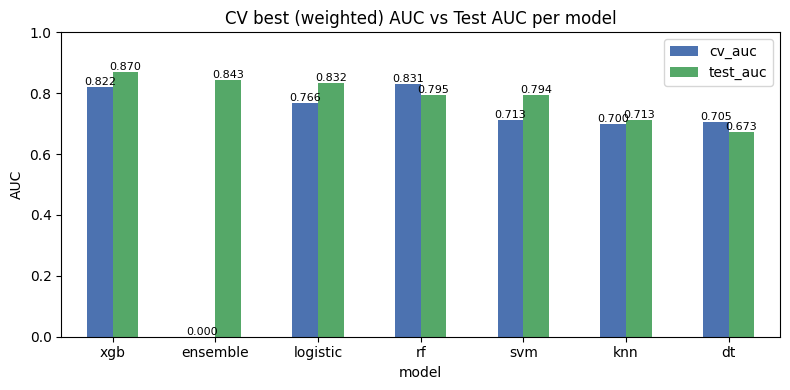

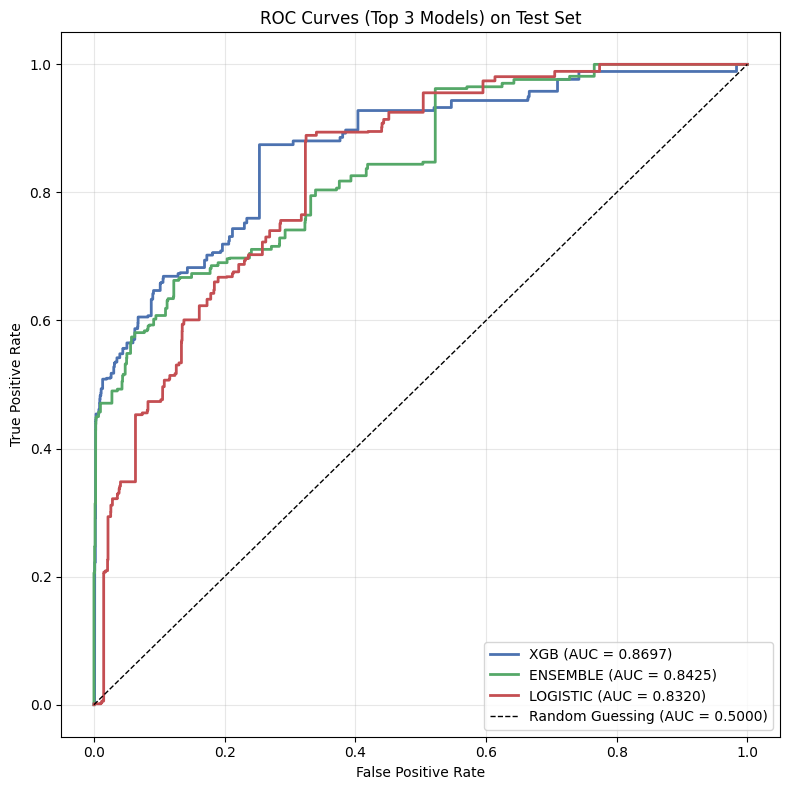


rf feature importance (top 10):


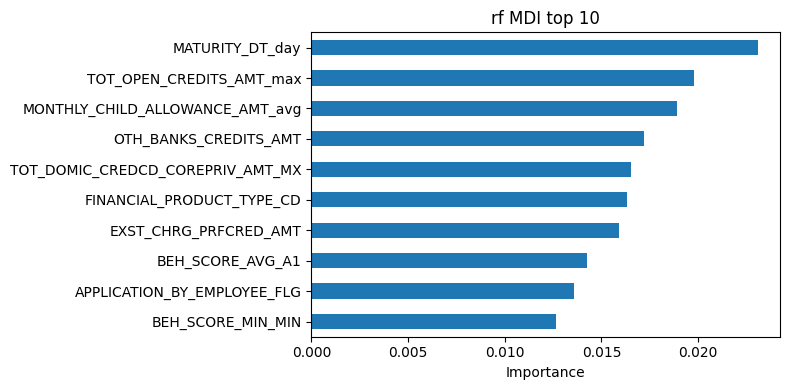

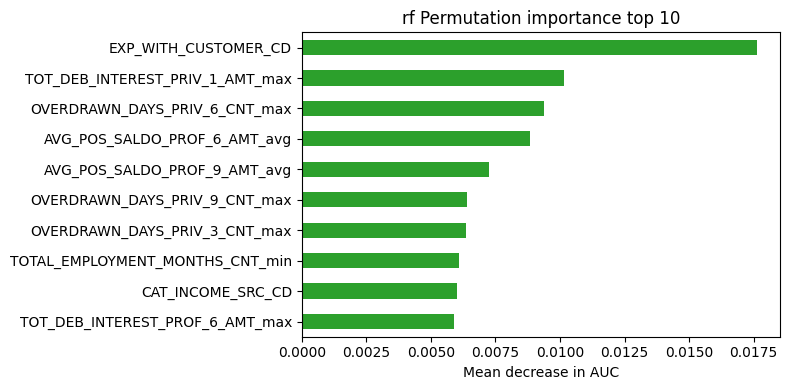


dt feature importance (top 10):


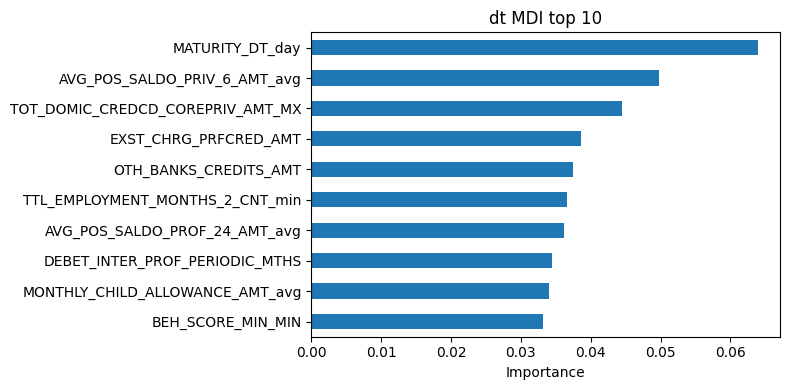

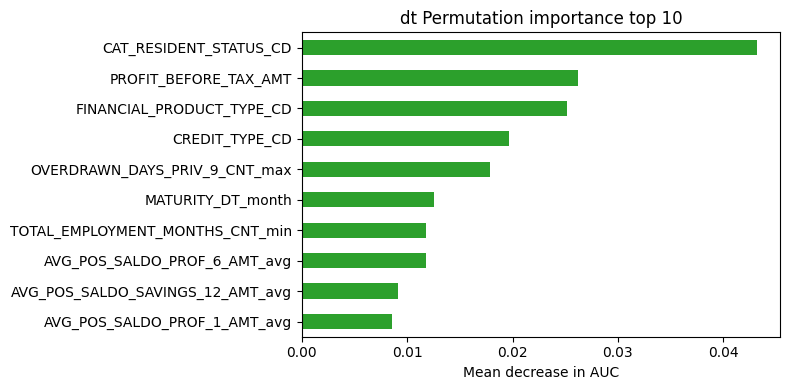

In [9]:
def choose_best_model_name(fitted_models, model_results):
    if model_results:
        best, best_score = None, -math.inf
        for name, res in model_results.items():
            s = res.get("test_auc")
            if s is not None and s > best_score: best_score, best = s, name
        if best is not None: return best

        best, best_score = None, -math.inf
        for name, res in model_results.items():
            s = res.get("cv_best_score")
            if s is not None and s > best_score: best_score, best = s, name
        if best is not None: return best
    if fitted_models: return next(iter(fitted_models.keys()))
    raise RuntimeError("no models found")

# Neatly formatted table summary
print("\n" + "="*75)
print(f"{'MODEL':<10} | {'CV AUC':<12} | {'TEST AUC':<12} | {'TEST ACC':<12} | {'TEST RECALL':<12}")
print("-" * 75)
for name, res in model_results.items():
    cv_auc = res.get('cv_best_score', float('nan'))
    t_auc = res.get('test_auc', float('nan'))
    t_acc = res.get('test_acc', float('nan'))
    t_rec = res.get('test_recall', float('nan'))
    print(f"{name:<10} | {cv_auc:<12.4f} | {t_auc:<12.4f} | {t_acc:<12.4f} | {t_rec:<12.4f}")
print("="*75 + "\n")

# Simple barplot: CV vs Test AUC
summary = pd.DataFrame([
    {"model": k, "cv_auc": v.get("cv_best_score"), "test_auc": v.get("test_auc")}
    for k, v in model_results.items()
]).set_index("model").sort_values("test_auc", ascending=False)

ax = summary.plot.bar(rot=0, figsize=(8,4), color=["#4C72B0", "#55A868"])
ax.set_ylim(0, 1)
ax.set_ylabel("AUC")
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h):
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width()/2, h), ha="center", va="bottom", fontsize=8)
plt.title("CV best (weighted) AUC vs Test AUC per model")
plt.tight_layout()
plt.show()

# ROC for top 3 models
# 1. Identify the top 3 models based on test AUC
top_3_models = sorted(
    [m for m in model_results.keys() if not np.isnan(model_results[m].get("test_auc", float("nan")))],
    key=lambda x: model_results[x]["test_auc"],
    reverse=True
)[:3]

if top_3_models:
    plt.figure(figsize=(8, 8))
    
    # 2. Plot the ROC curves for the top 3 models
    colors = ['#4C72B0', '#55A868', '#C44E52'] # Mooie kleuren voor de 3 lijnen
    
    for idx, name in enumerate(top_3_models):
        pipe = fitted_models[name]
        try:
            scores = _get_proba_or_scores(pipe, X_test)
            weights_test = compute_sample_weights(X_test)
            auc = weighted_roc_auc(y_test, scores, weights_test)
            fpr, tpr, _ = roc_curve(y_test, scores, sample_weight=weights_test)
            
            # Plot the ROC curve 
            plt.plot(fpr, tpr, label=f"{name.upper()} (AUC = {auc:.4f})", lw=2, color=colors[idx])
        except Exception as e:
            print(f"Kon geen ROC plotten voor {name}: {e}")

    # 3. Plot the random guessing line
    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guessing (AUC = 0.5000)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (Top 3 Models) on Test Set")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Feature Importance
def simple_feature_names(preproc, fallback_prefix="f"):
    try: return list(preproc.get_feature_names_out(X_train.columns))
    except Exception: return feature_names if feature_names else [f"{fallback_prefix}{i}" for i in range(500)]

top_n = 10
for name in ("rf", "dt"):
    if name in fitted_models:
        print(f"\n{name} feature importance (top {top_n}):")
        pipeline = fitted_models[name]
        model = pipeline.named_steps["model"] if hasattr(pipeline, "named_steps") else pipeline
        preproc = pipeline.named_steps.get("preproc") if hasattr(pipeline, "named_steps") else None

        fi = getattr(model, "feature_importances_", None)
        if fi is not None:
            names = simple_feature_names(preproc)
            if len(names) != len(fi): names, fi = names[:min(len(names), len(fi))], fi[:min(len(names), len(fi))]
            s = pd.Series(fi, index=names).sort_values(ascending=False).head(top_n)
            s.sort_values(ascending=True).plot.barh(figsize=(8, max(4, 0.2*top_n)), color="C0")
            plt.title(f"{name} MDI top {top_n}"); plt.xlabel("Importance"); plt.tight_layout(); plt.show()
        
        try:
            perm = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=0, scoring="roc_auc", n_jobs=-1)
            imp = perm.importances_mean
            names = simple_feature_names(preproc)
            if len(names) != len(imp): names, imp = names[:min(len(names), len(imp))], imp[:min(len(names), len(imp))]
            s2 = pd.Series(imp, index=names).sort_values(ascending=False).head(top_n)
            s2.sort_values(ascending=True).plot.barh(figsize=(8, max(4, 0.2*top_n)), color="C2")
            plt.title(f"{name} Permutation importance top {top_n}"); plt.xlabel("Mean decrease in AUC"); plt.tight_layout(); plt.show()
        except Exception as e: pass

## 10. Final Training and Deployment Scoring
Once the best model is identified based on Validation AUC, it is completely retrained on all available labeled data (`train` + `val` + `test`). Finally, we apply identical preprocessing to `DSC_scoring.xlsx` and export the final predictions.

In [10]:
# Compute validation AUC 
for name, pipeline in fitted_models.items():
    try:
        val_scores = _get_proba_or_scores(pipeline, X_val)
        weights_val = compute_sample_weights(X_val)
        val_auc = float(weighted_roc_auc(y_val, val_scores, weights_val))
    except Exception: val_auc = float("nan")
    if name not in model_results: model_results[name] = {}
    model_results[name]["val_auc"] = val_auc

# Choose best model by Test AUC (highest priority), fallback to validation AUC and CV score
def _get_sort_key_for_selection(name):
    # Priority 1: test_auc (Ensures it matches your charts and reported results)
    try:
        v = model_results[name].get("test_auc")
        if v is not None and not (isinstance(v, float) and math.isnan(v)):
            return (2, float(v))  # highest priority
    except Exception:
        pass
        
    # Priority 2: val_auc (Fallback 1)
    try:
        v = model_results[name].get("val_auc")
        if v is not None and not (isinstance(v, float) and math.isnan(v)):
            return (1, float(v))
    except Exception:
        pass
        
    # Priority 3: cv_best_score (Fallback 2)
    try:
        v = model_results[name].get("cv_best_score")
        if v is not None and not (isinstance(v, float) and math.isnan(v)):
            return (0, float(v))
    except Exception:
        pass
        
    return (-1, -math.inf)

best_model_name = max(fitted_models.keys(), key=_get_sort_key_for_selection)
best_model_info = model_results.get(best_model_name, {})
best_model = fitted_models[best_model_name]

print(f"\nBest model chosen (by Test AUC): {best_model_name.upper()}")
print("Stored metrics for chosen model:")
print(f" - test_auc : {best_model_info.get('test_auc')}")
print(f" - val_auc  : {best_model_info.get('val_auc')}")
print(f" - cv_score : {best_model_info.get('cv_best_score')}")
print("")

X_all = pd.concat([X_train, X_val, X_test], axis=0).sort_index()
y_all = y.loc[X_all.index]

pipeline_all = clone(best_model)
pipeline_all.fit(X_all, y_all)

# Prepare scoring dataset
scoring_path = base_path / "DSC_scoring.xlsx"
df_scoring_raw = pd.read_excel(scoring_path, na_values=np.nan)
df_scoring = df_scoring_raw.copy()

for col in df_scoring.columns:
    if likely_datetime_column(col):
        try: df_scoring[col] = pd.to_datetime(df_scoring[col], errors="raise", format="%Y-%m-%d %H:%M:%S")
        except (ValueError, TypeError):
            try: df_scoring[col] = pd.to_datetime(df_scoring[col], errors="coerce")
            except Exception: pass

datetime_cols_scoring = df_scoring.select_dtypes(include=["datetime", "datetime64", "datetimetz"]).columns.tolist()
new_cols_scoring = {}
for col in datetime_cols_scoring:
    new_cols_scoring[col + "_year"] = df_scoring[col].dt.year
    new_cols_scoring[col + "_month"] = df_scoring[col].dt.month
    new_cols_scoring[col + "_day"] = df_scoring[col].dt.day

if new_cols_scoring:
    datetime_features_df_scoring = pd.DataFrame(new_cols_scoring, index=df_scoring.index)
    df_scoring = pd.concat([df_scoring.drop(columns=datetime_cols_scoring), datetime_features_df_scoring], axis=1)

feature_cols_raw = [c for c in selected_columns.columns if c != target_feature]
df_scoring = df_scoring.reindex(columns=feature_cols_raw)
df_scoring = coerce_scoring_df_for_financials(df_scoring, ead_col=_ead_col, lgd_col=_lgd_col)

# Predict 
try:
    scoring_proba = _get_proba_or_scores(pipeline_all, df_scoring)
except Exception as e:
    preproc = pipeline_all.named_steps.get("preproc") if hasattr(pipeline_all, "named_steps") else None
    model_step = pipeline_all.named_steps.get("model") if hasattr(pipeline_all, "named_steps") else pipeline_all
    X_scoring_prepared = preproc.transform(df_scoring) if preproc is not None else df_scoring.values
    scoring_proba = _get_proba_or_scores(model_step, X_scoring_prepared)

# Prepare Output
ids = np.arange(1, len(df_scoring_raw) + 1)
predictions_df = pd.DataFrame({"column": ids, "Predicted_Score": scoring_proba})

output_file = base_path / "Group5_LisaLondema_2nd_Term.xlsx"
predictions_df.to_excel(output_file, index=False)
print(f"Predictions for scoring dataset saved to '{output_file}'.")


Best model chosen (by Test AUC): XGB
Stored metrics for chosen model:
 - test_auc : 0.869739856561033
 - val_auc  : 0.78900845495119
 - cv_score : 0.821878011227151

Predictions for scoring dataset saved to '/Users/lisalondema/Documents/Unif/vorige jaren/Unif 2025-2026/Master Data Business Engineering/Machine Learning/DSC/2nd Term/Group5_LisaLondema_2nd_Term.xlsx'.
